# Retriever vs Reranker Comparison
Compare embedding retriever (Qwen3-emb-4b) against LLM-based reranker (Qwen3-30B-Instruct) on TP labeling, precision/recall/nDCG, and ranking correlation.

In [3]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyrootutils import setup_root
from scipy.stats import spearmanr
import seaborn as sns

In [4]:
from patent_retrieval import utils

## Configuration & Data Loading

In [5]:
CLEF_IP = Path(os.environ["CLEF_IP_LOCATION"])

test_topics_path = CLEF_IP / "02_topics" / "test-pac" / "relass_clef-ip-2011-PAC_abs.txt"
candidates_path = "/home/alm3rng/patent-retrieval/embeddings/runs/patQwen3-emb-4b-v2_db-v4_abstract-claims_aysm_500topics_top1000/results.csv"
prefilter_results_path = "/home/alm3rng/patent-retrieval/reranking/runs/qwen3.5-397b_db-v4_thinking_ret-patQwen3-emb-4b_abstract_aysm_500topics_top100/results.csv"

In [6]:
topics_df = pd.read_csv(
    test_topics_path, sep="\t", header=None, skiprows=1, names=["q_id", "doc_id", "score"]
)
candidates_df = pd.read_csv(
    candidates_path, sep=",", header=None, skiprows=1, names=["q_id", "doc_id", "score"]
)
results_df = pd.read_csv(
    prefilter_results_path, sep=",", header=None, skiprows=1, names=["q_id", "doc_id", "score"]
)

# Filter candidates to topics present in reranker results
topics = results_df["q_id"].unique()
candidates_df = candidates_df[candidates_df["q_id"].isin(topics)]

## True Positive Labeling

In [7]:
# Label true positives in candidates
topics_lookup = topics_df.groupby("q_id")["doc_id"].apply(set).to_dict()
candidates_df["TP"] = candidates_df.apply(
    lambda r: int(r["doc_id"] in topics_lookup.get(r["q_id"], set())), axis=1
)
candidates_df[candidates_df["TP"] == 1]

,q_id,doc_id,score,TP
25,EP-1452422-A1,EP-0353995,0.768243,1
104,EP-1452422-A1,EP-1180665,0.708289,1
1014,EP-1394086-A1,EP-0168614,0.784412,1
1042,EP-1394086-A1,EP-0371464,0.748956,1
1378,EP-1394086-A1,EP-0317504,0.682427,1
...,...,...,...,...
499150,EP-1518464-A1,EP-0986962,0.645873,1
499241,EP-1518464-A1,EP-0897671,0.628501,1
499289,EP-1518464-A1,WO-1999015546,0.621796,1
499606,EP-1518464-A1,WO-1999015547,0.591531,1


In [8]:
# Label true positives in reranker results and attach cosine similarity from retriever
results_df["TP"] = results_df.apply(
    lambda r: int(r["doc_id"] in topics_lookup.get(r["q_id"], set())), axis=1
)
cand_scores = candidates_df.set_index(["q_id", "doc_id"])["score"]
results_df["cos_sim"] = results_df.apply(
    lambda r: cand_scores.get((r["q_id"], r["doc_id"]), np.nan), axis=1
)
results_df[results_df["TP"] == 1]

,q_id,doc_id,score,TP,cos_sim
2,EP-1223325-A1,WO-2001002210,0.045695,1,0.806434
100,EP-1225290-A2,EP-1061213,0.049180,1,0.825196
110,EP-1225290-A2,EP-0967350,0.039745,1,0.791381
176,EP-1225290-A2,EP-0903457,0.023114,1,0.782249
205,EP-1227590-A1,EP-0836280,0.044350,1,0.835421
...,...,...,...,...,...
49600,EP-1930214-A2,EP-0712758,0.048916,1,0.726823
49601,EP-1930214-A2,EP-0510345,0.047907,1,0.781456
49800,EP-1935503-A1,WO-1998053917,0.048916,1,0.806504
49811,EP-1935503-A1,EP-0486378,0.037633,1,0.815624


## Precision / Recall / nDCG at K

In [11]:
candidates_df

,q_id,doc_id,score,TP
0,EP-1452422-A1,EP-1167927,0.840976,0
1,EP-1452422-A1,EP-0349968,0.835616,0
2,EP-1452422-A1,EP-0381963,0.821297,0
3,EP-1452422-A1,EP-1167163,0.817540,0
4,EP-1452422-A1,EP-0983929,0.813599,0
...,...,...,...,...
499995,EP-1518464-A1,EP-0940084,0.570390,0
499996,EP-1518464-A1,WO-2000056745,0.570359,0
499997,EP-1518464-A1,WO-1997045021,0.570352,0
499998,EP-1518464-A1,WO-2001072148,0.570335,0


In [12]:

candidates_metrics = utils.calculate_metrics(candidates_df.iloc[:,:3],topk=100)
candidates_metrics

{'accuracy@5': 0.15319999999999998,
 'precision@5': 0.15319999999999998,
 'recall@5': 0.17870037740037742,
 'f1@5': 0.15668787120523694,
 'nDCG@5': 0.388401364081746,
 'accuracy@10': 0.11120000000000002,
 'precision@10': 0.11120000000000002,
 'recall@10': 0.2542725496725497,
 'f1@10': 0.1477164109963114,
 'nDCG@10': 0.42408512533507503,
 'accuracy@20': 0.07690000000000001,
 'precision@20': 0.07690000000000001,
 'recall@20': 0.345415478965479,
 'f1@20': 0.12136945399656562,
 'nDCG@20': 0.4372712446416198,
 'accuracy@50': 0.04216,
 'precision@50': 0.04216,
 'recall@50': 0.467378576978577,
 'f1@50': 0.07585502573235245,
 'nDCG@50': 0.43991239191788173,
 'accuracy@100': 0.025800000000000003,
 'precision@100': 0.025800000000000003,
 'recall@100': 0.5721207348207348,
 'f1@100': 0.04882594364055357,
 'nDCG@100': 0.4414847953103333}

In [13]:
results_metrics = utils.calculate_metrics(results_df.iloc[:,:3],topk=100)
results_metrics

{'accuracy@5': 0.18359999999999999,
 'precision@5': 0.18359999999999999,
 'recall@5': 0.2164984570984571,
 'f1@5': 0.18979472991404878,
 'nDCG@5': 0.4421446523445203,
 'accuracy@10': 0.1322,
 'precision@10': 0.1322,
 'recall@10': 0.30976507381507384,
 'f1@10': 0.17694052214308775,
 'nDCG@10': 0.4707751005397872,
 'accuracy@20': 0.0884,
 'precision@20': 0.0884,
 'recall@20': 0.4101390664890664,
 'f1@20': 0.14039902546318042,
 'nDCG@20': 0.48473185431208293,
 'accuracy@50': 0.04556,
 'precision@50': 0.04556,
 'recall@50': 0.514264219114219,
 'f1@50': 0.08210225425153024,
 'nDCG@50': 0.48714137705127086,
 'accuracy@100': 0.025800000000000003,
 'precision@100': 0.025800000000000003,
 'recall@100': 0.5721207348207348,
 'f1@100': 0.04882594364055357,
 'nDCG@100': 0.48680081038630835}

## Ranking Correlation (Spearman)

In [14]:
# Spearman rank correlation between retriever and reranker per topic
def compute_spearman_per_topic(cand_df, result_df):
    scores = []
    for topic in result_df["q_id"].unique():
        cand = cand_df[cand_df["q_id"] == topic]
        res = result_df[result_df["q_id"] == topic]
        common = set(cand["doc_id"]) & set(res["doc_id"])
        if len(common) < 2:
            continue
        cand_rank = {d: r for r, d in enumerate(cand[cand["doc_id"].isin(common)].nlargest(len(common), "score")["doc_id"])}
        res_rank = {d: r for r, d in enumerate(res[res["doc_id"].isin(common)].nlargest(len(common), "score")["doc_id"])}
        corr, _ = spearmanr([cand_rank[d] for d in common], [res_rank[d] for d in common])
        scores.append(corr)
    return np.mean(scores) if scores else 0, scores

avg_spearman, spearman_scores = compute_spearman_per_topic(candidates_df, results_df)
print(f"Average Spearman Correlation: {avg_spearman:.4f}")
print(f"Per-topic: {[f'{s:.4f}' for s in spearman_scores]}")

Average Spearman Correlation: 0.3372
Per-topic: ['0.0627', '0.5045', '0.2179', '0.2680', '0.4807', '0.2640', '0.5202', '0.2179', '0.4224', '0.2050', '0.5819', '0.3993', '0.2195', '0.1199', '0.4015', '0.3750', '0.2342', '0.1148', '0.6111', '0.4438', '0.3414', '0.5127', '0.2062', '0.1177', '0.7160', '0.1806', '0.3491', '0.2137', '0.4278', '0.3347', '0.4257', '0.1370', '-0.1877', '0.1943', '0.1562', '0.4576', '0.2141', '0.2950', '0.3260', '0.1102', '0.5208', '0.4635', '0.4817', '0.4373', '0.5318', '0.4229', '0.5029', '0.6096', '0.3486', '0.3813', '0.2340', '0.4408', '0.5517', '0.3264', '0.3546', '0.4115', '-0.0272', '0.5037', '0.3688', '0.2872', '0.3873', '0.2213', '0.2737', '0.2093', '0.0913', '0.2366', '0.2090', '0.3048', '0.0492', '0.5123', '0.1081', '0.4617', '0.3373', '0.4038', '0.4370', '0.3459', '0.5433', '0.3709', '0.1230', '0.3261', '0.4103', '0.3834', '0.4243', '0.4250', '0.4451', '0.4118', '0.2060', '0.5726', '0.5528', '0.4032', '0.6961', '0.5313', '0.7988', '0.6394', '0.1898',

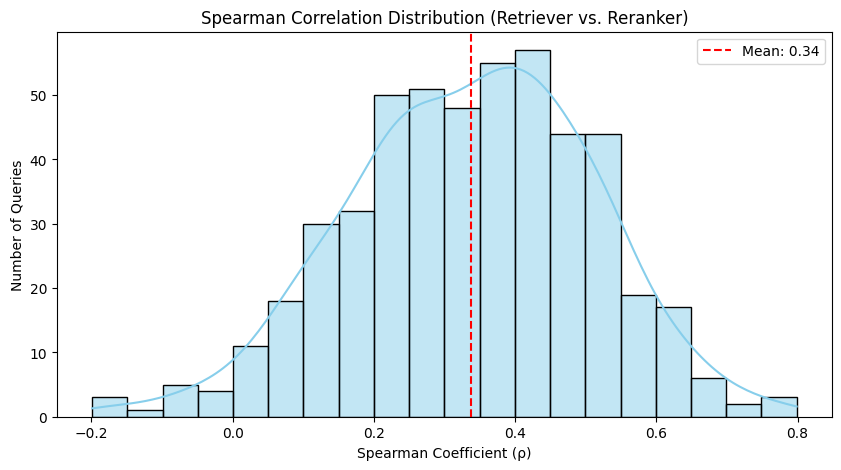

In [15]:
# Distribution of Spearman correlations across topics
plt.figure(figsize=(10, 5))
sns.histplot(spearman_scores, kde=True, color="skyblue", bins=20)
plt.axvline(np.mean(spearman_scores), color="red", linestyle="--", label=f"Mean: {np.mean(spearman_scores):.2f}")
plt.title("Spearman Correlation Distribution (Retriever vs. Reranker)")
plt.xlabel("Spearman Coefficient (ρ)")
plt.ylabel("Number of Queries")
plt.legend()
plt.show()

## Summary

### Setup
- **Retriever**: patQwen3-emb-4b (embedding-based, cosine similarity)
- **Reranker**: Qwen3.5-397B (LLM-based, pointwise scoring with thinking)
- **Dataset**: CLEF-IP 2011 PAC, 500 topics, top-100 candidates from retriever passed to reranker

### Key Findings

**True Positive Labeling**
- Both the retriever and reranker surfaces are annotated with ground-truth TP labels. The reranker results also carry the original cosine similarity from the retriever, enabling direct comparison of how each system ranks the same documents.

**Precision / Recall / nDCG**
- Metrics are computed at cutoffs [10, 20, 30, 50, 100] for both systems.
- The reranker is expected to improve **precision at low K** (better ranking of relevant docs near the top) while operating within the retriever's recall ceiling (it can only reorder what the retriever retrieved).

**Ranking Correlation (Spearman)**
- Per-topic Spearman ρ measures how much the reranker reorders the retriever's ranking.
- A low average ρ indicates the reranker substantially changes the ordering — useful when paired with improved nDCG, as it means the reranker is correcting retriever mistakes.
- A high ρ would suggest the reranker largely agrees with the retriever, adding little value.

### Interpretation Guide
| Scenario | ρ | nDCG change | Meaning |
|---|---|---|---|
| Reranker helps | Low | ↑ | Reranker corrects bad retriever rankings |
| Reranker agrees | High | ≈ | Retriever already ranks well, reranker redundant |
| Reranker hurts | Low | ↓ | Reranker introduces noise |